In [5]:
!pip install langgraph langchain_openai langchain_community python-dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-azure-ai 0.1.5 requires langchain-core<0.4.0,>=0.3.0, but you have langchain-core 1.3.3 which is incompatible.
langchain-azure-ai 0.1.5 requires langchain-openai<0.4.0,>=0.3.0, but you have langchain-openai 1.2.1 which is incompatible.
langchain-huggingface 0.3.1 requires langchain-core<1.0.0,>=0.3.70, but you have langchain-core 1.3.3 which is incompatible.
streamlit 1.45.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.0 which is incompatible.


  Using cached langgraph-1.1.10-py3-none-any.whl.metadata (8.0 kB)
  Using cached langchain_core-1.3.3-py3-none-any.whl.metadata (4.5 kB)
  Using cached langgraph_checkpoint-4.0.3-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.0.13-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.3.14-py3-none-any.whl.metadata (1.7 kB)
  Using cached langchain_protocol-0.0.15-py3-none-any.whl.metadata (2.4 kB)
INFO: pip is looking at multiple versions of langchain-openai to determine which version is compatible with other requirements. This could take a while.
  Using cached langchain_openai-1.2.1-py3-none-any.whl.metadata (3.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
INFO: pip is looking at multiple versions of langchain to determine which version is compatible with other requirements. This could take a while.
Using cached langgraph-1.1.10-py3-none-any.whl (173 kB)
Using cached langchain_core-1.3.3-py3-none-any.whl (543 kB)

c:\Users\megha\anaconda3\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [6]:
load_dotenv()

False

In [7]:
llm = ChatOpenAI()

OpenAIError: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.

In [59]:
# Tools
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()


In [60]:
# Make tool list
tools = [get_stock_price, search_tool, calculator]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [62]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [63]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

In [71]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [72]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")    

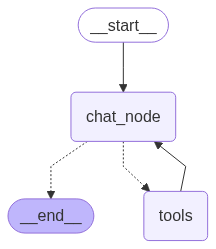

In [73]:
chatbot = graph.compile()

chatbot

In [74]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)


Hello! How can I assist you today?


In [75]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]})
print(out["messages"][-1].content)

The result of 2 multiplied by 3 is 6.


In [76]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

The stock price of Apple (AAPL) is $227.76.


In [78]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

The current stock price of Apple (AAPL) is $227.76 per share. 

To purchase 50 shares of Apple, it would cost $11,388.00.
